In [29]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from skimage.feature import graycomatrix, graycoprops
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [30]:
healthImg = 'data/healthy'
diseaseImg = 'data/diseased'

imgSize = (128, 128)
imgCount = 100

In [31]:
def load_images (folder, label, count=100):
    images =[]
    labels =[]
    paths = []

    allFiles = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selectedFiles = random.sample(allFiles, min(count, len(allFiles)))

    for fileName in selectedFiles:
        path = os.path.join(folder, fileName)
        img = cv2.imread(path)

        if img is None:
            continue
        
        img = cv2.resize(img, imgSize)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        images.append(img)
        labels.append(label)
        paths.append(path)

    return images, labels, paths

random.seed(42)

healthy_imgs, healthy_labels, healthy_paths = load_images(healthImg, label=0, count=imgCount)
diseased_imgs, diseased_labels, diseased_paths = load_images(diseaseImg, label=1, count=imgCount)

all_images = healthy_imgs + diseased_imgs
all_labels = healthy_labels + diseased_labels

print(f"Healthy Images Count:  {len(healthy_imgs)}")
print(f"Diseased Images Count: {len(diseased_imgs)}")
print(f"Total Image Count: {len(all_images)}")

Healthy Images Count:  100
Diseased Images Count: 100
Total Image Count: 200


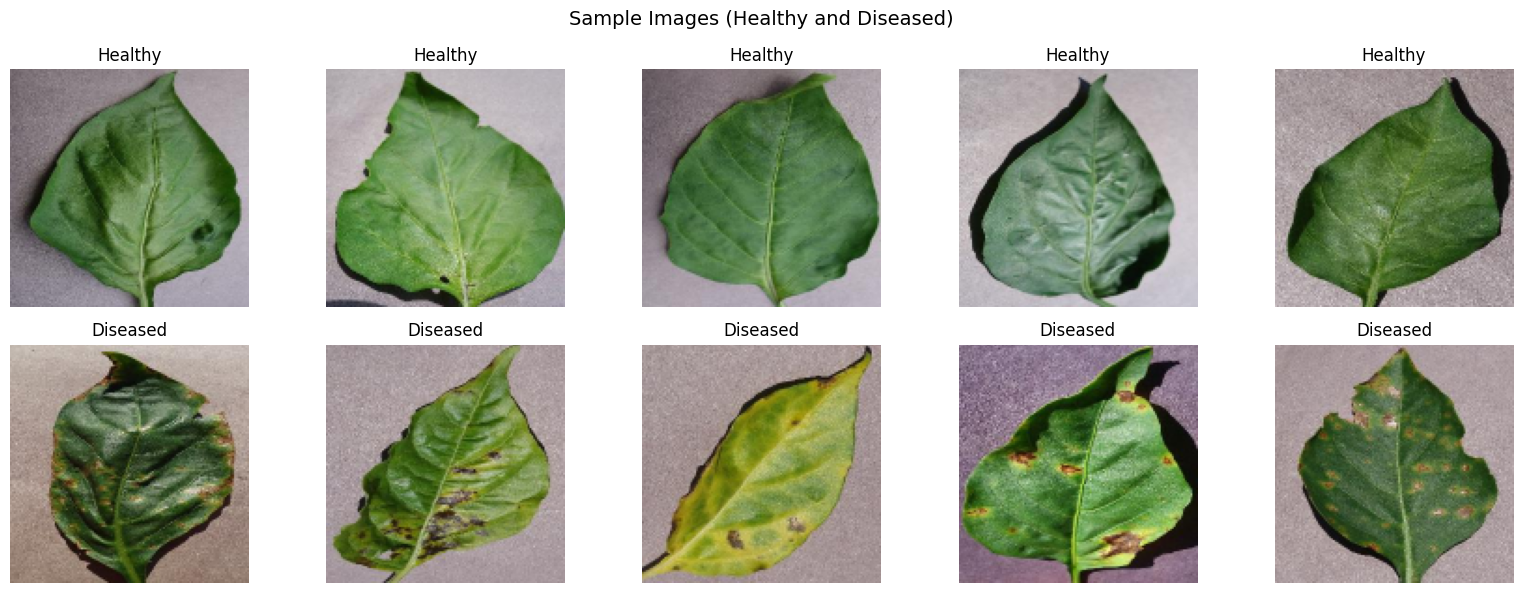

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Sample Images (Healthy and Diseased)', fontsize=14)

for i in range(5):
    axes[0, i].imshow(healthy_imgs[i])
    axes[0, i].axis('off')
    axes[0, i].set_title('Healthy')

    axes[1, i].imshow(diseased_imgs[i])
    axes[1, i].axis('off')
    axes[1, i].set_title('Diseased')

plt.tight_layout()
plt.savefig('out/output_samples.png', dpi=150)
plt.show()

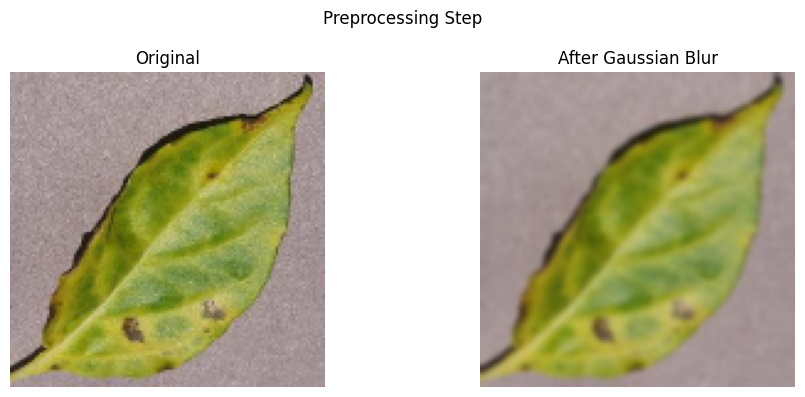

In [33]:
def preprocessingImg  (img): #Adding Blur to reduce Noise
    blurredImg = cv2.GaussianBlur(img, (5, 5), 0)
    return blurredImg

sampleTesting = diseased_imgs[2]
processedImg = preprocessingImg(sampleTesting)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sampleTesting)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(processedImg)
axes[1].set_title('After Gaussian Blur')
axes[1].axis('off')
plt.suptitle('Preprocessing Step')
plt.tight_layout()
plt.savefig('out/output_preprocessing.png', dpi=150)
plt.show()

In [34]:
def getDiseaseMask(img):
    blurred = preprocessingImg(img)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)

    #Healthy green area mask
    lowerG = np.array([25, 40, 40])
    upperG = np.array([85, 255, 255])
    maskG = cv2.inRange(hsv, lowerG, upperG)
    #Disease Brown Yellow Spots Mask
    lowerB = np.array([5, 50, 50])
    upperB = np.array([15, 255, 255])
    maskB = cv2.inRange(hsv, lowerB, upperB)

    kernel = np.ones((3,3), np.uint8)
    maskB = cv2.morphologyEx(maskB, cv2.MORPH_OPEN, kernel)
    maskB = cv2.morphologyEx(maskB, cv2.MORPH_DILATE, kernel)

    return maskG, maskB

def getDiseasePercentage(maskB, maskG):
    total = cv2.countNonZero(maskG) + cv2.countNonZero(maskB)
    if total == 0:
        return 0.0
    return (cv2.countNonZero(maskB) / total) * 100

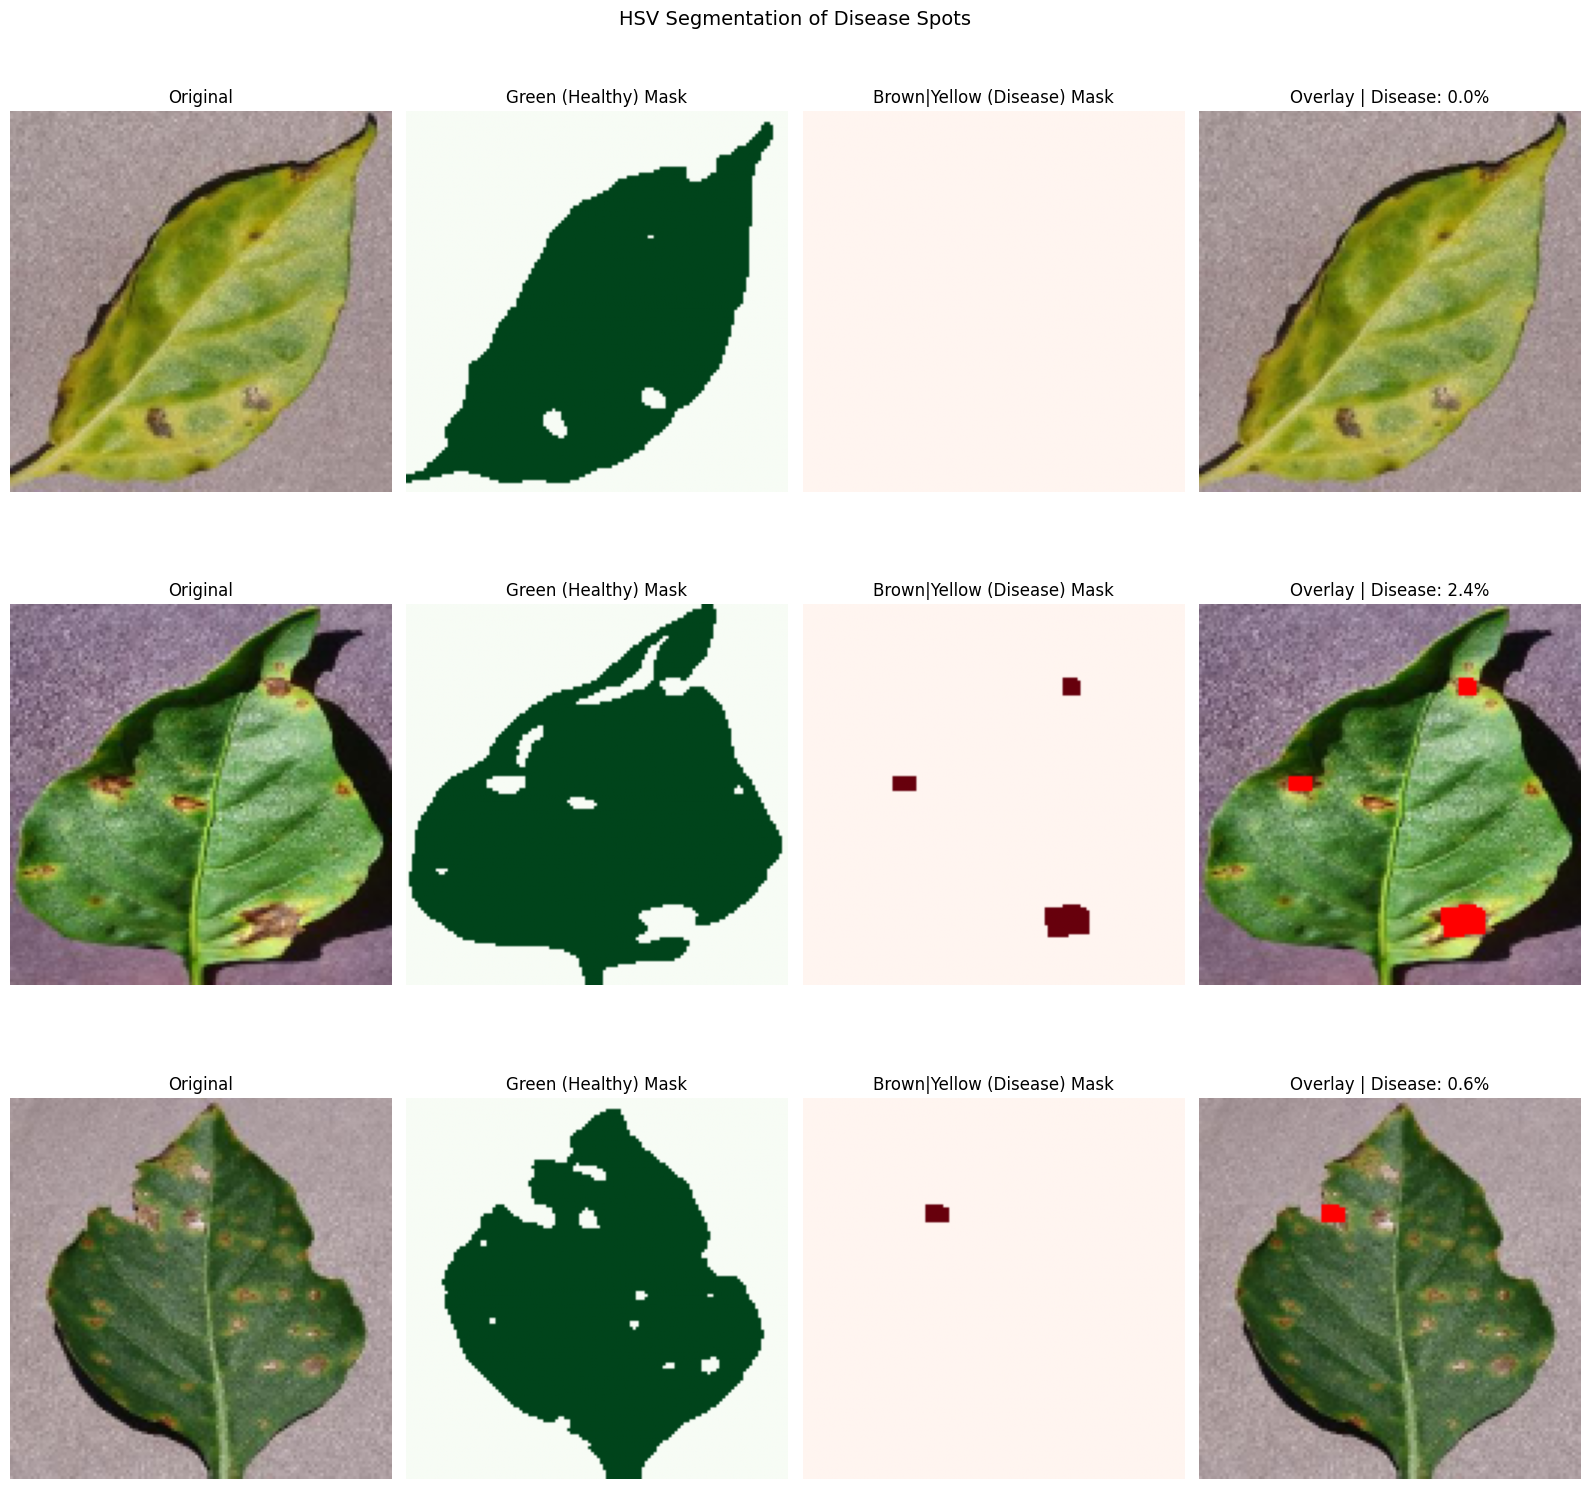

In [41]:
fig, axes = plt.subplots(3, 4, figsize=(16, 16))
fig.suptitle('HSV Segmentation of Disease Spots', fontsize=14)

for i in range(3):
    img = diseased_imgs[i + 2]
    maskG, maskB = getDiseaseMask(img)
    pct = getDiseasePercentage(maskB, maskG)

    overlay = img.copy()
    overlay[maskB > 0] = [255, 0, 0]

    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(maskG, cmap='Greens')
    axes[i, 1].set_title('Green (Healthy) Mask')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(maskB, cmap='Reds')
    axes[i, 2].set_title('Brown|Yellow (Disease) Mask')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(overlay)
    axes[i, 3].set_title(f'Overlay | Disease: {pct:.1f}%')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('out/output_segmentation.png', dpi=150)
plt.show()

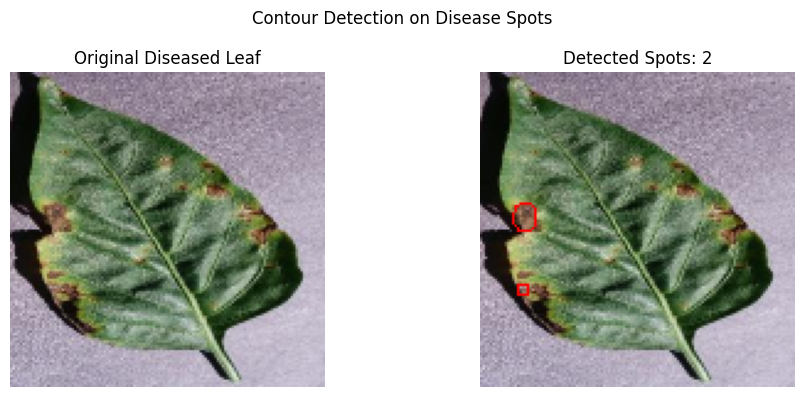

In [38]:
sampleDiseased = diseased_imgs[9]
_, maskB = getDiseaseMask(sampleDiseased)

contours, _ = cv2.findContours(maskB, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = [c for c in contours if cv2.contourArea(c) > 10]

contour_img = sampleDiseased.copy()
cv2.drawContours(contour_img, contours, -1, (255, 0, 0), 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sampleDiseased)
axes[0].set_title('Original Diseased Leaf')
axes[0].axis('off')
axes[1].imshow(contour_img)
axes[1].set_title(f'Detected Spots: {len(contours)}')
axes[1].axis('off')
plt.suptitle('Contour Detection on Disease Spots')
plt.tight_layout()
plt.savefig('out/output_contours.png', dpi=150)
plt.show()
